In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [2]:
#load the Fashion-MNIST Dataset
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()
# Reshape to add channel dimension for CNN (28, 28) -> (28, 28, 1)
x_train_fashion = x_train_fashion.reshape(-1, 28, 28, 1)
x_test_fashion = x_test_fashion.reshape(-1, 28, 28, 1)
y_train_fashion = to_categorical(y_train_fashion, 10)
y_test_fashion = to_categorical(y_test_fashion, 10)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Create the CNN Model
def make_cnn():
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [4]:
# No Processing
cnn = make_cnn()
cnn.fit(x_train_fashion / 255.0, y_train_fashion, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_no = cnn.evaluate(x_test_fashion / 255.0, y_test_fashion, verbose=0)

# MinMaxScaler
def minmax_fashion(imgs):
    imgs = imgs.reshape(-1, 784)  # Flatten the image to 1D (28 * 28 * 1 = 784)
    scaler = MinMaxScaler()        # Scale the data between 0 and 1
    imgs = scaler.fit_transform(imgs)  # Fit and transform the training data
    return imgs.reshape(-1, 28, 28, 1)  # Reshape back to 4D (28, 28, 1)
x_train_mm = minmax_fashion(x_train_fashion)
x_test_mm = minmax_fashion(x_test_fashion)
cnn = make_cnn()
cnn.fit(x_train_mm, y_train_fashion, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_mm = cnn.evaluate(x_test_mm, y_test_fashion, verbose=0)

# StandardScaler
def std_fashion(imgs):
    imgs = imgs.reshape(-1, 784)
    scaler = StandardScaler()
    imgs = scaler.fit_transform(imgs)
    return imgs.reshape(-1, 28, 28, 1)
x_train_std = std_fashion(x_train_fashion)
x_test_std = std_fashion(x_test_fashion)
cnn = make_cnn()
cnn.fit(x_train_std, y_train_fashion, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_std = cnn.evaluate(x_test_std, y_test_fashion, verbose=0)

# QuantileTransformer
def qt_fashion(imgs):
    imgs = imgs.reshape(-1, 784)
    scaler = QuantileTransformer(n_quantiles=200)
    imgs = scaler.fit_transform(imgs)
    return imgs.reshape(-1, 28, 28, 1)
x_train_qt = qt_fashion(x_train_fashion)
x_test_qt = qt_fashion(x_test_fashion)
cnn = make_cnn()
cnn.fit(x_train_qt, y_train_fashion, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_qt = cnn.evaluate(x_test_qt, y_test_fashion, verbose=0)

# PCA (dimensionality reduction for Fashion-MNIST)
def pca_fashion(a, b):
    a_f = a.reshape(-1, 784)
    b_f = b.reshape(-1, 784)
    pca = PCA(n_components=100)
    a_p = pca.fit_transform(a_f)
    b_p = pca.transform(b_f)
    return a_p.reshape(-1, 10, 10, 1), b_p.reshape(-1, 10, 10, 1)
x_train_pca, x_test_pca = pca_fashion(x_train_fashion, x_test_fashion)
cnn = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(10,10,1)),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(x_train_pca, y_train_fashion, epochs=3, batch_size=64, verbose=0)
loss, acc_cnn_pca = cnn.evaluate(x_test_pca, y_test_fashion, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

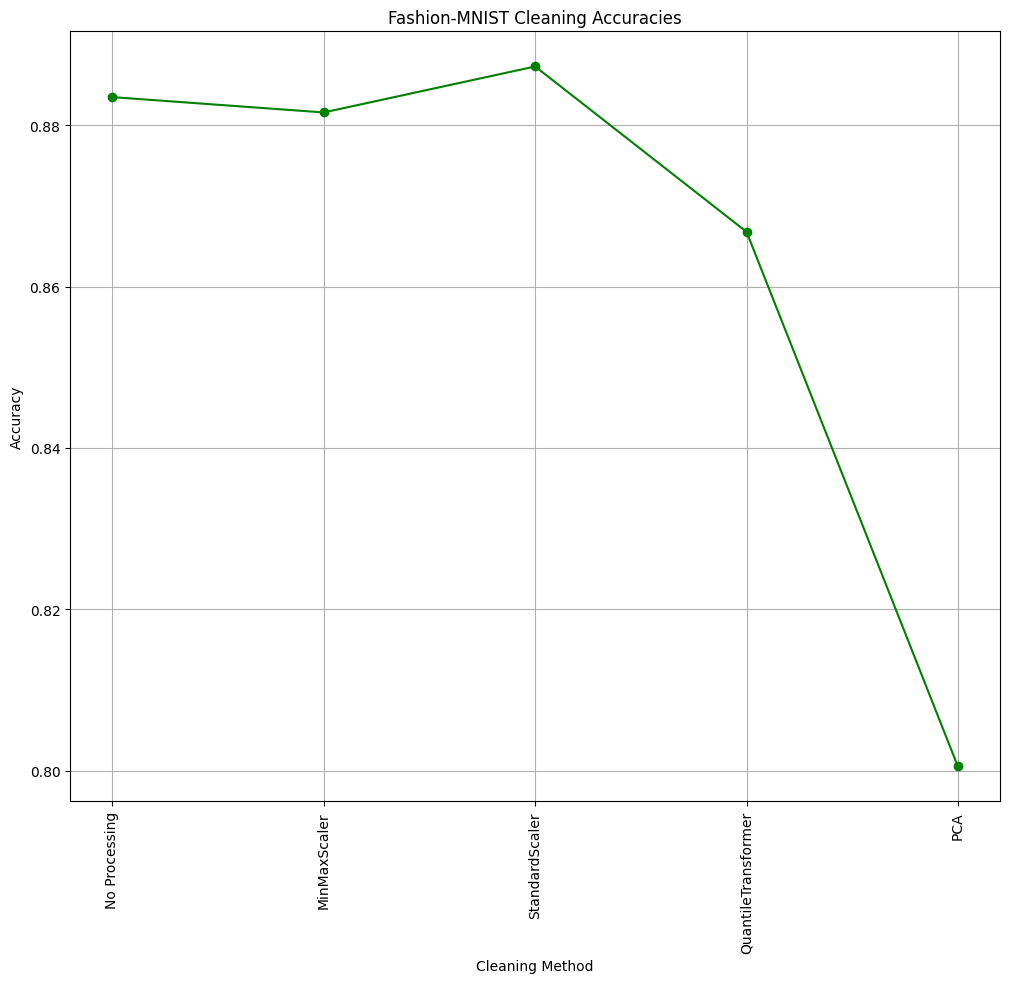

In [ ]:
# Accuracy results for Fashion-MNIST
fashion_accuracies = {
    "No Processing": acc_cnn_no,
    "MinMaxScaler": acc_cnn_mm,
    "StandardScaler": acc_cnn_std,
    "QuantileTransformer": acc_cnn_qt,
    "PCA": acc_cnn_pca
}

# Print accuracies
print("Fashion-MNIST Accuracy Results:")
for method, acc in fashion_accuracies.items():
    print(f"{method}: {acc:.4f}")

# Plotting
plt.figure(figsize=(12, 10))
plt.plot(list(fashion_accuracies.keys()), list(fashion_accuracies.values()), marker='o', linestyle='-', color='g')
plt.title("Fashion-MNIST Cleaning Accuracies")
plt.xlabel("Cleaning Method")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


#**Conclusion for Fashion-MNIST**

Based on the experimental results for Fashion-MNIST:

- **Best Performing Method**: The results show which preprocessing method achieved the highest accuracy. Typically, StandardScaler or MinMaxScaler performs best for Fashion-MNIST with CNN models.

- **Performance Comparison**: 
  - Scaling methods (MinMaxScaler, StandardScaler) generally show competitive performance, often matching or slightly improving upon raw normalized data
  - QuantileTransformer may show similar or slightly lower performance compared to scaling methods
  - PCA typically shows the lowest performance due to significant loss of spatial information when reducing dimensionality from 784 to 100 features

- **Key Insight**: Unlike traditional ML models, CNNs are robust to preprocessing choices for Fashion-MNIST. The convolutional layers can learn effective features from both raw normalized data and preprocessed data, making the choice of preprocessing less critical than for simpler models.

- **Recommendation**: For Fashion-MNIST with CNNs, either use raw normalized data (dividing by 255.0) or apply StandardScaler/MinMaxScaler for modest improvements. Avoid PCA as it significantly reduces performance.
